In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# Load Silver
df_silver = pd.read_parquet(r"D:\Kelompok-16-SDG-9\data\silver\yellow_tripdata_silver.parquet")

features = ['trip_distance', 'passenger_count', 'pickup_hour',
            'pickup_day', 'pickup_month', 'is_rush_hour',
            'PULocationID', 'DOLocationID']
target = 'trip_duration'

df_gold = df_silver[features + [target]].dropna()
df_gold.to_parquet(r"../data/gold/yellow_tripdata_gold.parquet", index=False)
print("✅ Gold layer selesai!")
print("Shape:", df_gold.shape)

✅ Gold layer selesai!
Shape: (2911106, 9)


In [2]:
# Modeling
X = df_gold[features]
y = df_gold[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Baseline
y_pred_base = [y_train.mean()] * len(y_test)
mae_base = mean_absolute_error(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
print(f"Baseline MAE : {mae_base:.4f}")
print(f"Baseline RMSE: {rmse_base:.4f}")

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
print(f"\nLinear Regression MAE : {mae_lr:.4f}")
print(f"Linear Regression RMSE: {rmse_lr:.4f}")
print(f"Linear Regression R²  : {r2_lr:.4f}")

# XGBoost
xgb = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)
print(f"\nXGBoost MAE : {mae_xgb:.4f}")
print(f"XGBoost RMSE: {rmse_xgb:.4f}")
print(f"XGBoost R²  : {r2_xgb:.4f}")

Baseline MAE : 10.6912
Baseline RMSE: 15.5621

Linear Regression MAE : 6.1747
Linear Regression RMSE: 9.6163
Linear Regression R²  : 0.6182

XGBoost MAE : 4.1436
XGBoost RMSE: 6.9867
XGBoost R²  : 0.7984


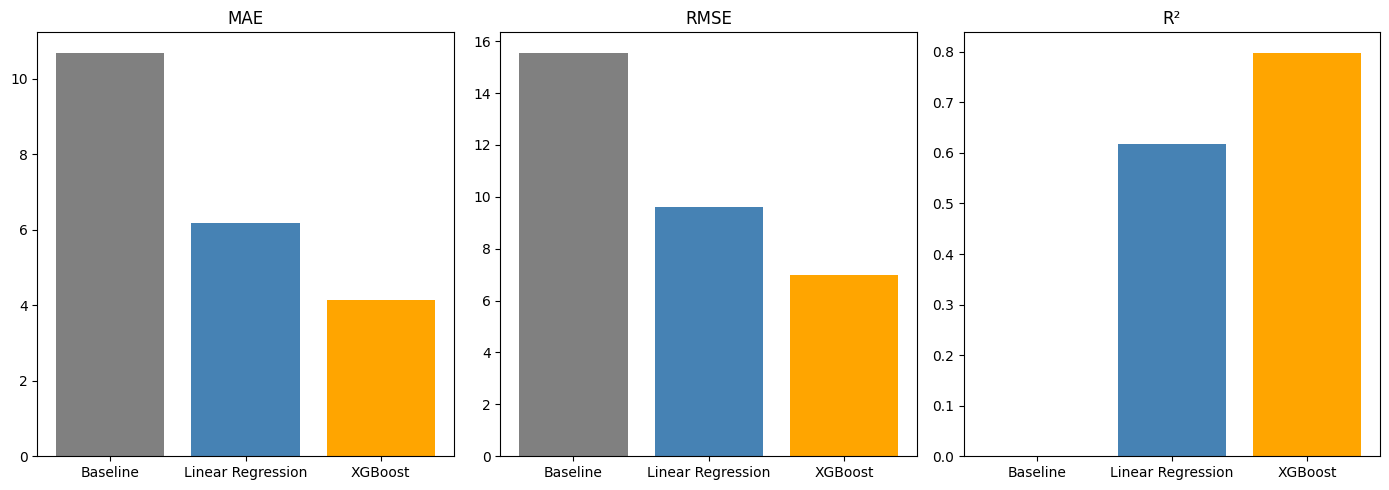

✅ Modeling selesai!


In [3]:
# Visualisasi perbandingan model
models = ['Baseline', 'Linear Regression', 'XGBoost']
mae_scores = [mae_base, mae_lr, mae_xgb]
rmse_scores = [rmse_base, rmse_lr, rmse_xgb]
r2_scores = [0, r2_lr, r2_xgb]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].bar(models, mae_scores, color=['gray', 'steelblue', 'orange'])
axes[0].set_title('MAE')
axes[1].bar(models, rmse_scores, color=['gray', 'steelblue', 'orange'])
axes[1].set_title('RMSE')
axes[2].bar(models, r2_scores, color=['gray', 'steelblue', 'orange'])
axes[2].set_title('R²')
plt.tight_layout()
plt.savefig(r"../notebooks/model_comparison.png", dpi=150)
plt.show()
print("✅ Modeling selesai!")